# 538 — Alex-sequenced Tier 1 model + fit

**Purpose:** Walk `5-Manuscript/Alex_Tier1_Sequential_Model_Outline.md` in order. This notebook builds the **data map** (\(Y\), \(L\) proxies, \(A\), diagnostics) the same way as **`535`**, but drops heavy **CELL 4 EDA** charts — those stay in `535` to avoid duplicate figures.

**Run order:** EDIT BLANK (log) → **CELL 0** → **CELL 1** → **CELL 2** → **CELL 3** → **CELL 4** (binned means) → **CELL 4B** (exploratory Q × peer SD hexbin) → **CELL 5** (LPM + \(L^*\)) → **CELL 6** (logit + \(L^*\) in index space). Each numbered CELL is a **markdown** header immediately followed by a **code** cell whose first line is `# CELL N — …`. **Headers** start with **Does:** (what the next code cell *runs* or *produces*), then details and prerequisites.

- **Reference panel:** `datasets/mbb/player_season_panel_530.csv` via `sports_pipeline.paths.panel_530_csv()` (refresh with **`530_sports_pipeline.ipynb`** when you need a new export).
- **Simulation / comparative statics:** `537_Sports_Simulation.ipynb` only.

In [1]:
# EDIT BLANK — session log
##### EDIT BLANK ###### DISCARD
# session: 2026-05-18 10:28 — CELL 4C: 3D surface via SciPy binned_statistic_2d (after user SciPy install).
# - Session marker: 2026-05-18 10:28 — CELL 4C: 3D surface mean Y_draft vs LOO Q × peer SD (same sample as 4B).
# - Session marker: 2026-05-18 10:27 — CELL 4B: histogram LOO peer mean Q excluding exact zeros.
# - Session marker: 2026-05-18 10:14 — CELL 4A: line plot draft rate vs bin mean L (CELL 4 companion).
# - Session marker: 2026-05-16 21:06 — 538: CELL markdown headers add “Does” (what each cell does).
# - Session marker: 2026-05-15 14:45 — CELL 6 logit (same index as CELL 5) + L* in z-space.
# - Session marker: 2026-05-15 14:27 — CELL 4–5 binned table + z-scored LPM and L*.
# - Session marker: 2026-05-15 12:49 — CELL 0–3 Alex scaffold (no 535 CELL4 EDA).
# - Session marker: 2026-05-15 16:20 — CELL 0: add RUN_CELL6 switch + uncomment print.
# - Session marker: 2026-05-15 16:32 — CELL 6: fix Logit res.params indexing (ndarray / Series).
# - Session marker: 2026-05-16 20:49 — CELL 4B: hexbin mean Q × LOO peer perf SD vs draft rate.
# - Session marker: 2026-05-16 21:06 — CELL 4A: line plot draft rate vs bin mean L (CELL 4 companion).
# - Session marker: 2026-05-18 10:14 — CELL 4B: histogram LOO peer mean Q excluding exact zeros.
# - Session marker: 2026-05-18 10:27 — CELL 4C: 3D surface mean Y_draft vs LOO Q × peer SD.



### CELL 0 — Config · `RUN_CELL*` · knobs for Alex pipeline

**Does:** Sets **run gates** (`RUN_CELL1` … `RUN_CELL6`, `RUN_CELL4B`) and **Tier 1 knobs** (`PERF_METRIC`, `PRIMARY_POOL_MODE`, minutes filter, crowding); prints one line summarizing them. Does **not** load the panel.

Switchboard for **538** only. Gates **CELL 1–6** and **CELL 4B** (… → binned table → **Q×SD hexbin** → LPM → **logit**). **No** 535-style dual-panel figure switches — use **`535`** for heavy EDA plots.

Re-run this code cell after changing any flag.

In [30]:
# CELL 0 — Config · RUN_CELL* · knobs for Alex pipeline

# --- Run gates (re-run CELL 0 after changes) ---
RUN_CELL1 = True  # Environment · imports · CFG · panel path
RUN_CELL2 = True  # Load panel · perf · legacy poolq_loo
RUN_CELL3 = True  # Tier 1 mechanism columns (congestion_*)
RUN_CELL4 = True  # Alex §6 step 1 — binned mean Y vs L (table only)
RUN_CELL4B = True  # Exploratory — hexbin: LOO peer mean Q × LOO peer perf SD vs draft rate
RUN_CELL5 = True  # Alex §6 step 2 — LPM Y ~ L + L² + A on z-scores; print L*
RUN_CELL6 = True  # Alex §6 step 3 — logit same index as CELL 5; L* in z / raw L

# --- Panel / Tier 1 (consumed by CELL 2–3 and later fit cells) ---
# PERF_METRIC = "ppm"
PERF_METRIC = "minutes"

# Rows below this minutes threshold dropped before Tier 1 group stats; None = keep all.
MIN_MINUTES_TIER1 = None

# "quality" → L proxy path favors congestion_quality (Tier 1 Q); "crowding" → crowding cols.
PRIMARY_POOL_MODE = "quality"
COMPUTE_WEIGHTED_CROWDING = False

print(
    "538 CELL 0:",
    f"RUN_CELL1={RUN_CELL1}",
    f"RUN_CELL2={RUN_CELL2}",
    f"RUN_CELL3={RUN_CELL3}",
    f"RUN_CELL4={RUN_CELL4}",
    f"RUN_CELL4B={RUN_CELL4B}",
    f"RUN_CELL5={RUN_CELL5}",
    f"RUN_CELL6={RUN_CELL6}",
    f"PERF_METRIC={PERF_METRIC!r}",
    f"PRIMARY_POOL_MODE={PRIMARY_POOL_MODE!r}",
    f"COMPUTE_WEIGHTED_CROWDING={COMPUTE_WEIGHTED_CROWDING}",
)

538 CELL 0: RUN_CELL1=True RUN_CELL2=True RUN_CELL3=True RUN_CELL4=True RUN_CELL4B=True RUN_CELL5=True RUN_CELL6=True PERF_METRIC='minutes' PRIMARY_POOL_MODE='quality' COMPUTE_WEIGHTED_CROWDING=False


## CELL 1 — Environment · imports · panel path

**Does:** Imports pipeline modules, builds **`CFG`** (`PipelineConfig`: seasons, ventiles, winsor, z-score flags, …), and prints the **panel CSV path** / whether the file exists. Prepares globals for **`load_panel`** in CELL 2.

**Alex outline:** sets up **§4 Map model to data** — same `PipelineConfig` + `panel_530_csv()` contract as **`535`**, without pulling in CELL 4 plotting helpers.

- Run **CELL 0** first.
- For an exact fresh panel, export from **`530_sports_pipeline.ipynb`** before loading here.

In [37]:
# CELL 1 — Environment · imports · panel path
from __future__ import annotations

if RUN_CELL1:
    from sports_pipeline import paths
    from sports_pipeline.panel_build import load_panel
    from sports_pipeline.config import PipelineConfig

    # Match 530 / 535 defaults; tighten binning in later fit cells if needed (Alex ladder starts descriptive).
    CFG = PipelineConfig(
        panel_season_min=2011,
        panel_season_max=2021,
        ventiles=20,
        poolq_binning="quantile",
        poolq_winsor_quantiles=(0.05, 0.95),
        # poolq_winsor_quantiles=(0.0, 1.0),
        perf_zscore_within_season=False,
        restrict_teams_by_draftees=False,
        draftee_restriction="season",
        min_minutes=0.0,
    )
    PANEL_PATH = paths.panel_530_csv()
    print("Panel CSV:", PANEL_PATH)
    print("Exists:", PANEL_PATH.is_file())
else:
    print("  CELL 1 skipped  (RUN_CELL1 = False in CELL 0)")

Panel CSV: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/player_season_panel_530.csv
Exists: True


### CELL 2 — Load panel · `perf` · legacy `poolq_loo`

**Does:** Calls **`load_panel` → `apply_perf_metric_for_analysis`**, building **`df`** with **`Y_draft`**, **`perf`** (from `PERF_METRIC`), and recomputed **legacy `poolq_loo`** aligned to that `perf`.

**Data map (Tier1_Briefing_Outline §4):** outcome **`Y_draft`**, own performance **`perf`**, legacy leave-self-out pool quality **`poolq_loo`**. Same `load_panel` + `apply_perf_metric_for_analysis` as **`535` CELL 2** — no extra logic.

In [38]:
# CELL 2 — Load panel · perf · legacy poolq_loo

if RUN_CELL2:
    if "CFG" not in globals():
        print("  CELL 2 skipped — CFG undefined; run CELL 0 then CELL 1.")
    else:
        import pandas as pd

        from sports_pipeline.panel_build import apply_perf_metric_for_analysis

        df = load_panel(CFG)
        smin = getattr(CFG, "panel_season_min", None)
        smax = getattr(CFG, "panel_season_max", None)
        if smin is not None:
            df = df.loc[pd.to_numeric(df["season"], errors="coerce") >= smin]
        if smax is not None:
            df = df.loc[pd.to_numeric(df["season"], errors="coerce") <= smax]
        df = apply_perf_metric_for_analysis(
            df,
            PERF_METRIC,
            poolq_winsor_quantiles=CFG.poolq_winsor_quantiles,
            zscore_perf_within_season=CFG.perf_zscore_within_season,
        )

        assert "Y_draft" in df.columns, "Panel must include Y_draft"
        assert "poolq_loo" in df.columns
        assert "minutes" in df.columns
else:
    print("  CELL 2 skipped  (RUN_CELL2 = False in CELL 0)")

### CELL 3 — Tier 1 mechanism variables (`congestion_quality` · `congestion_crowding`)

**Does:** Runs **`add_tier1_mechanism_variables`** on **`df`**, adding **`congestion_quality`**, **`peer_perf_sd_loo`**, **`congestion_crowding`** (and optional weighted crowding); sets **`ALEX_L_COL`** from **`PRIMARY_POOL_MODE`**.

**Data map:** adds Tier 1 **`congestion_quality`** (strict valid-`perf` LOO mean), **`peer_perf_sd_loo`** (LOO sample SD of teammate `perf` among valid teammates), and crowding columns — same `add_tier1_mechanism_variables` as **`535` CELL 3**.

Sets **`primary_x`**: the default pool column for **\(L\)** in later fit cells, from `PRIMARY_POOL_MODE` / `COMPUTE_WEIGHTED_CROWDING` in CELL 0. (Legacy **`poolq_loo`** remains available for side-by-side specs.)

In [39]:
# CELL 3 — Tier 1 mechanism variables (congestion_quality · congestion_crowding)

if RUN_CELL3:
    if "df" not in globals():
        print("  CELL 3 skipped — df not defined; run CELL 2 or set RUN_CELL2 = True.")
    else:
        from sports_pipeline.tier1_mechanism_vars import (
            add_tier1_mechanism_variables,
            TIER1_QUALITY_COL,
            TIER1_CROWDING_COL,
            TIER1_CROWDING_WEIGHTED_COL,
            tier1_primary_pool_column,
        )

        df = add_tier1_mechanism_variables(
            df,
            min_minutes=MIN_MINUTES_TIER1,
            minutes_col="minutes",
            perf_col="perf",
            compute_weighted_crowding=COMPUTE_WEIGHTED_CROWDING,
        )

        if PRIMARY_POOL_MODE == "crowding" and COMPUTE_WEIGHTED_CROWDING:
            primary_x = TIER1_CROWDING_WEIGHTED_COL
        else:
            primary_x = tier1_primary_pool_column(PRIMARY_POOL_MODE)

        # Default amalgamated-L proxy for Alex §6 ladder (override in a later cell if needed).
        ALEX_L_COL = primary_x

        print(
            TIER1_QUALITY_COL,
            TIER1_CROWDING_COL,
            TIER1_CROWDING_WEIGHTED_COL,
            "primary_x=",
            primary_x,
            "ALEX_L_COL=",
            ALEX_L_COL,
        )
else:
    print("  CELL 3 skipped  (RUN_CELL3 = False in CELL 0)")

congestion_quality congestion_crowding congestion_crowding_weighted primary_x= congestion_quality ALEX_L_COL= congestion_quality


### CELL 4 — Descriptive bins (Alex §6 step 1)

**Does:** **Bins** `ALEX_L_COL` with **`assign_poolq_bin_labels`**, aggregates **`Y_draft`** (count and mean = draft rate) per bin, **displays** the resulting table — no plot.

**No figure** — only a **table** of mean `Y_draft` by bins of **`ALEX_L_COL`**, using the same **`CFG.ventiles`** and **`CFG.poolq_binning`** as 530/535 (`assign_poolq_bin_labels`).

**Sample:** `filter_panel(df, CFG)` then drop rows missing **`ALEX_L_COL`**, **`perf`**, **`Y_draft`** (matches the spirit of the EDA+LPM sample; heavy plots stay in **`535`**).

In [40]:
# CELL 4 — Descriptive bins on ALEX_L_COL (table only)

if RUN_CELL4:
    if "df" not in globals() or "ALEX_L_COL" not in globals():
        print("  CELL 4 skipped — run CELL 3 first.")
    elif "CFG" not in globals():
        print("  CELL 4 skipped — CFG missing; run CELL 1.")
    else:
        import pandas as pd
        from IPython.display import display

        from sports_pipeline.panel_build import assign_poolq_bin_labels, filter_panel

        use_alex = filter_panel(df, CFG)
        use_alex = use_alex.dropna(subset=[ALEX_L_COL, "perf", "Y_draft"])
        n_bins = int(CFG.ventiles)
        mode = str(CFG.poolq_binning)

        work = use_alex.copy()
        work["alex_bin"] = assign_poolq_bin_labels(work[ALEX_L_COL], n_bins, mode)
        work = work.dropna(subset=["alex_bin"])

        alex_bin_tab = (
            work.groupby("alex_bin", observed=True)
            .agg(
                n=("Y_draft", "size"),
                draft_rate=("Y_draft", "mean"),
                L_mean=(ALEX_L_COL, "mean"),
            )
            .reset_index()
            .sort_values("alex_bin")
        )

        print(
            f"CELL 4: n={len(use_alex):,} | bins={n_bins} | poolq_binning={mode!r} | L={ALEX_L_COL!r}"
        )
        display(alex_bin_tab)
else:
    print("  CELL 4 skipped  (RUN_CELL4 = False in CELL 0)")

CELL 4: n=104,789 | bins=20 | poolq_binning='quantile' | L='congestion_quality'


,alex_bin,n,draft_rate,L_mean
0,0,5240,0.000000,6.029091
1,1,5239,0.000000,8.292555
2,2,5240,0.000191,10.085405
3,3,5239,0.000000,11.583501
4,4,5240,0.000000,12.992398
5,5,5239,0.000000,15.307789
6,6,5240,0.000000,20.766113
7,7,5239,0.000000,27.850077
8,8,5240,0.002290,94.614798
9,9,5239,0.009926,269.055379


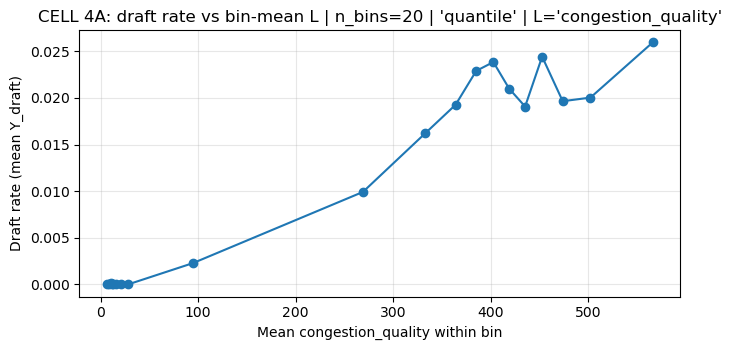

In [41]:
# CELL 4A — Figure paired with CELL 4 (draft rate vs pool-quality bin)

if RUN_CELL4:
    if "df" not in globals() or "ALEX_L_COL" not in globals():
        print("  CELL 4A skipped — run CELL 3 first.")
    elif "CFG" not in globals():
        print("  CELL 4A skipped — CFG missing; run CELL 1.")
    else:
        import matplotlib.pyplot as plt
        import pandas as pd

        from sports_pipeline.panel_build import assign_poolq_bin_labels, filter_panel

        use_alex = filter_panel(df, CFG)
        use_alex = use_alex.dropna(subset=[ALEX_L_COL, "perf", "Y_draft"])
        n_bins = int(CFG.ventiles)
        mode = str(CFG.poolq_binning)

        work = use_alex.copy()
        work["alex_bin"] = assign_poolq_bin_labels(work[ALEX_L_COL], n_bins, mode)
        work = work.dropna(subset=["alex_bin"])

        alex_bin_tab = (
            work.groupby("alex_bin", observed=True)
            .agg(
                n=("Y_draft", "size"),
                draft_rate=("Y_draft", "mean"),
                L_mean=(ALEX_L_COL, "mean"),
            )
            .reset_index()
            .sort_values("alex_bin")
        )

        fig, ax = plt.subplots(figsize=(7, 3.6))
        ax.plot(
            alex_bin_tab["L_mean"],
            alex_bin_tab["draft_rate"],
            marker="o",
            linestyle="-",
            color="C0",
        )
        ax.set_xlabel(f"Mean {ALEX_L_COL} within bin")
        ax.set_ylabel("Draft rate (mean Y_draft)")
        ax.set_title(
            f"CELL 4A: draft rate vs bin-mean L | n_bins={n_bins} | {mode!r} | L={ALEX_L_COL!r}"
        )
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()
else:
    print("  CELL 4A skipped  (RUN_CELL4 = False in CELL 0)")


### CELL 4B — Exploratory mean \(Q\) × peer SD vs draft (Paper Directions 11)

**Does:** After `filter_panel` + `dropna` on Q, peer SD, `perf`, and `Y_draft`, draws a **hexbin** with **x** = `congestion_quality`, **y** = `peer_perf_sd_loo`, **color** = mean **`Y_draft`**, and prints sample size / hex settings.

**Hexbin:** *x* = **LOO peer mean `perf`** (`congestion_quality`, \(Q\)); *y* = **LOO peer `perf` SD** (`peer_perf_sd_loo` from CELL 3); color = **mean `Y_draft`** in each hex. **Associational** diagnostic — hypothesis from meeting: tight peer spread (low SD) may relate to stronger nonlinearity / “crowding”; high SD may ease peer distinction.

**Needs:** **CELL 0** `RUN_CELL4B=True`, **CELL 1–3** (so `peer_perf_sd_loo` exists). The plot **always** uses **`congestion_quality`** on the x-axis even when **`PRIMARY_POOL_MODE`** is `'crowding'` (mean pool ability / Paper Directions 11).

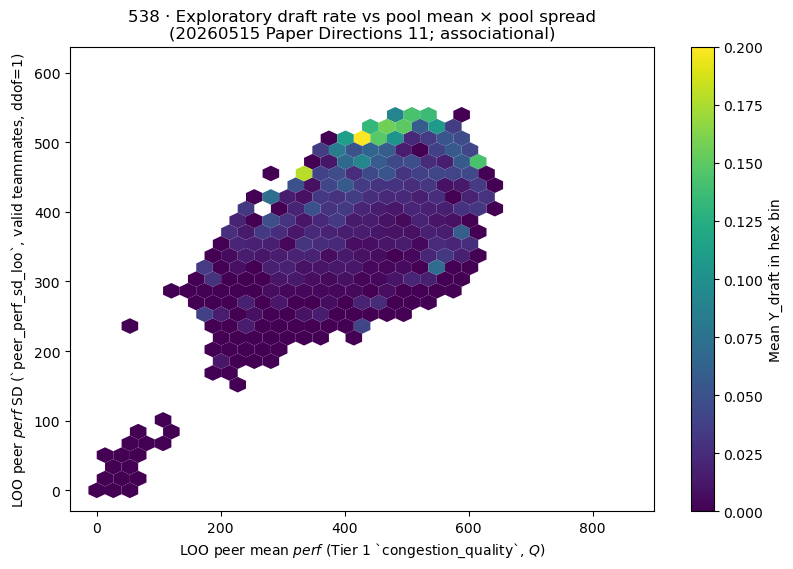

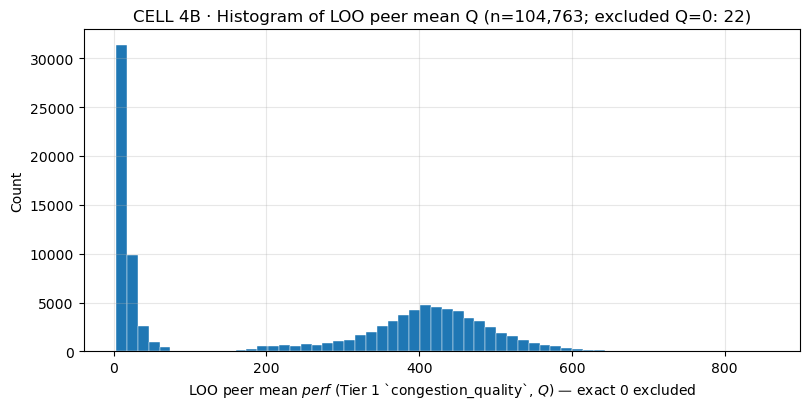

CELL 4B: n=104,785 after dropna(['congestion_quality', 'peer_perf_sd_loo', 'perf', 'Y_draft']) | hex gridsize=32 mincnt=20 | PRIMARY_POOL_MODE='quality' (x-axis is always 'congestion_quality') | hist Q: n_nonzero=104,763, n_Q_eq_0=22


In [42]:
# CELL 4B — Hexbin: LOO peer mean Q × LOO peer perf SD vs draft rate

if RUN_CELL4B:
    if "df" not in globals() or "ALEX_L_COL" not in globals():
        print("  CELL 4B skipped — run CELL 3 first.")
    elif "CFG" not in globals():
        print("  CELL 4B skipped — CFG missing; run CELL 1.")
    else:
        import matplotlib.pyplot as plt
        import numpy as np

        from sports_pipeline.panel_build import filter_panel
        from sports_pipeline.tier1_mechanism_vars import TIER1_PEER_PERF_SD_LOO_COL, TIER1_QUALITY_COL

        Q_COL = TIER1_QUALITY_COL
        SD_COL = TIER1_PEER_PERF_SD_LOO_COL

        use_h = filter_panel(df, CFG)
        need = [Q_COL, SD_COL, "perf", "Y_draft"]
        use_h = use_h.dropna(subset=need)
        n0 = len(use_h)

        HEX_GRID = 32
        HEX_MINCNT = 20

        fig, ax = plt.subplots(figsize=(8.2, 5.8))
        hb = ax.hexbin(
            use_h[Q_COL].to_numpy(dtype=float),
            use_h[SD_COL].to_numpy(dtype=float),
            C=use_h["Y_draft"].to_numpy(dtype=float),
            reduce_C_function=np.mean,
            gridsize=HEX_GRID,
            mincnt=HEX_MINCNT,
            cmap="viridis",
            edgecolors="none",
        )
        cb = fig.colorbar(hb, ax=ax)
        cb.set_label("Mean Y_draft in hex bin")
        ax.set_xlabel(r"LOO peer mean $perf$ (Tier 1 `congestion_quality`, $Q$)")
        ax.set_ylabel(r"LOO peer $perf$ SD (`peer_perf_sd_loo`, valid teammates, ddof=1)")
        ax.set_title(
            "538 · Exploratory draft rate vs pool mean × pool spread\n"
            "(20260515 Paper Directions 11; associational)"
        )
        fig.tight_layout()
        plt.show()

        q_all = use_h[Q_COL].to_numpy(dtype=float)
        mask_nz = q_all != 0
        q_nz = q_all[mask_nz]
        n_q_zero = int(np.sum(~mask_nz))
        fig2, ax2 = plt.subplots(figsize=(8.2, 4.2))
        ax2.hist(q_nz, bins=60, color="C0", edgecolor="white", linewidth=0.3)
        ax2.set_xlabel(
            r"LOO peer mean $perf$ (Tier 1 `congestion_quality`, $Q$) — exact 0 excluded"
        )
        ax2.set_ylabel("Count")
        ax2.set_title(
            f"CELL 4B · Histogram of LOO peer mean Q "
            f"(n={len(q_nz):,}; excluded Q=0: {n_q_zero:,})"
        )
        ax2.grid(True, alpha=0.3)
        fig2.tight_layout()
        plt.show()

        print(
            f"CELL 4B: n={n0:,} after dropna({need}) | hex gridsize={HEX_GRID} mincnt={HEX_MINCNT} | "
            f"PRIMARY_POOL_MODE={PRIMARY_POOL_MODE!r} (x-axis is always {Q_COL!r}) | "
            f"hist Q: n_nonzero={len(q_nz):,}, n_Q_eq_0={n_q_zero:,}"
        )
else:
    print("  CELL 4B skipped  (RUN_CELL4B = False in CELL 0)")


In [ ]:
# CELL 4C — 3D surface: mean Y_draft vs LOO Q × peer SD (SciPy `binned_statistic_2d`; same sample as 4B)

if RUN_CELL4B:
    if "df" not in globals() or "ALEX_L_COL" not in globals():
        print("  CELL 4C skipped — run CELL 3 first.")
    elif "CFG" not in globals():
        print("  CELL 4C skipped — CFG missing; run CELL 1.")
    else:
        import matplotlib.pyplot as plt
        import numpy as np
        from scipy.stats import binned_statistic_2d

        from sports_pipeline.panel_build import filter_panel
        from sports_pipeline.tier1_mechanism_vars import TIER1_PEER_PERF_SD_LOO_COL, TIER1_QUALITY_COL

        Q_COL = TIER1_QUALITY_COL
        SD_COL = TIER1_PEER_PERF_SD_LOO_COL

        use_h = filter_panel(df, CFG)
        need = [Q_COL, SD_COL, "perf", "Y_draft"]
        use_h = use_h.dropna(subset=need)

        x = use_h[Q_COL].to_numpy(dtype=float)
        y = use_h[SD_COL].to_numpy(dtype=float)
        c = use_h["Y_draft"].to_numpy(dtype=float)

        SURF_GRID = 40
        ret = binned_statistic_2d(x, y, c, statistic="mean", bins=SURF_GRID)
        Z = ret.statistic
        xe, ye = ret.x_edge, ret.y_edge
        xc = (xe[:-1] + xe[1:]) / 2
        yc = (ye[:-1] + ye[1:]) / 2
        X, Y = np.meshgrid(xc, yc, indexing="ij")

        fig = plt.figure(figsize=(9, 6.2))
        ax = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(
            X,
            Y,
            Z,
            cmap="viridis",
            linewidth=0,
            antialiased=True,
            alpha=0.95,
        )
        ax.set_xlabel(r"LOO peer mean $Q$ (`congestion_quality`)")
        ax.set_ylabel(r"LOO peer $perf$ SD (`peer_perf_sd_loo`)")
        ax.set_zlabel("Mean Y_draft (bin)")
        ax.set_title(
            "538 · CELL 4C — mean draft rate vs (Q, peer SD)\n"
            f"(SciPy 2D mean bins={SURF_GRID}; associational; gated like CELL 4B)"
        )
        fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.08, label="Mean Y_draft")
        fig.tight_layout()
        plt.show()

        n_finite = int(np.sum(np.isfinite(Z)))
        print(
            f"CELL 4C: n={len(use_h):,} | surface bins={SURF_GRID}×{SURF_GRID} | "
            f"cells_with_data={n_finite} | requires scipy.stats.binned_statistic_2d"
        )
else:
    print("  CELL 4C skipped  (RUN_CELL4B = False in CELL 0)")


### CELL 5 — Minimal quadratic LPM + \(L^*\) (Alex §6 step 2)

**Does:** Builds analysis sample (same filters as earlier cells), z-scores **`ALEX_L_COL`** and **`perf`**, fits **OLS** **`Y_draft ~ 1 + Lz + Lz² + Az`**, prints fitted coefficients and the **interior turning point** \(L^*\) in z-units and mapped back to raw \(L\).

**Spec:** linear probability model \(Y \sim 1 + \tilde L + \tilde L^2 + \tilde A\) where \(\tilde L,\tilde A\) are **within-sample z-scores** of **`ALEX_L_COL`** and **`perf`**.

**Interior turning point** (if \(\hat\beta_2 \neq 0\)): \(\tilde L^* = -\hat\beta_1 / (2\hat\beta_2)\), mapped back to raw \(L\) as \(\bar L + s_L \tilde L^*\).

**Next:** **CELL 6** fits the **same index** with **logit**; \(\Pr(Y{=}1)=\Lambda(\beta_0+\beta_1\tilde L+\beta_2\tilde L^2+\beta_3\tilde A)\). With only \(\tilde L\) and \(\tilde L^2\) nonlinear, the **argmax of the linear index** (hence of fitted probability) is still \(\tilde L^*=-\hat\beta_1/(2\hat\beta_2)\).

In [9]:
# CELL 5 — Quadratic LPM on z-scores; L* in z and raw L units

if RUN_CELL5:
    if "df" not in globals() or "ALEX_L_COL" not in globals():
        print("  CELL 5 skipped — run CELL 3 first.")
    elif "CFG" not in globals():
        print("  CELL 5 skipped — CFG missing; run CELL 1.")
    else:
        import numpy as np

        from sports_pipeline.panel_build import filter_panel

        use_alex = filter_panel(df, CFG)
        use_alex = use_alex.dropna(subset=[ALEX_L_COL, "perf", "Y_draft"])

        L = use_alex[ALEX_L_COL].astype(float).to_numpy()
        A = use_alex["perf"].astype(float).to_numpy()
        y = use_alex["Y_draft"].astype(float).to_numpy()

        Lz = (L - L.mean()) / L.std(ddof=0)
        Az = (A - A.mean()) / A.std(ddof=0)
        X = np.column_stack([np.ones(len(y)), Lz, Lz * Lz, Az])
        mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
        beta, *_ = np.linalg.lstsq(X[mask], y[mask], rcond=None)
        b0, b1, b2, b3 = beta

        print(
            f"CELL 5: OLS LPM  Y ~ 1 + Lz + Lz^2 + Az   (n={int(mask.sum()):,}, L={ALEX_L_COL!r})"
        )
        print(f"  beta_const={b0:.6f}  beta_Lz={b1:.6f}  beta_Lz2={b2:.6f}  beta_Az={b3:.6f}")

        if abs(b2) < 1e-12:
            print("  L* not defined (beta_Lz2 ~ 0).")
        else:
            Lstar_z = -b1 / (2 * b2)
            L_mean = float(L.mean())
            L_std = float(L.std(ddof=0))
            Lstar_raw = L_mean + L_std * Lstar_z
            print(f"  L* (z-score units) = {Lstar_z:.6f}")
            print(f"  L* (raw {ALEX_L_COL}) ≈ {Lstar_raw:.6f}")
            if b2 >= 0:
                print("  Note: beta_Lz2 >= 0 — no concave interior maximum; interpret shape cautiously.")
else:
    print("  CELL 5 skipped  (RUN_CELL5 = False in CELL 0)")

CELL 5: OLS LPM  Y ~ 1 + Lz + Lz^2 + Az   (n=82,887, L='congestion_quality')
  beta_const=0.015010  beta_Lz=0.002851  beta_Lz2=-0.001305  beta_Az=0.010683
  L* (z-score units) = 1.092590
  L* (raw congestion_quality) ≈ 0.326679


### CELL 6 — Logit (same \(\tilde L,\tilde A\) index) + \(L^*\)

**Does:** Reuses the **same rows and z-scores** as CELL 5, fits **MLE logit** `Y_draft ~ 1 + Lz + Lz² + Az`, prints the parameter vector and **\(L^*\)** from the linear index (same formula as CELL 5 when \(\hat\beta_2<0\)).

**Needs:** `statsmodels` (`pip install statsmodels`).

**\(L^*\):** for coefficients \((\hat\beta_1,\hat\beta_2)\) on \((\tilde L,\tilde L^2)\), \(\tilde L^* = -\hat\beta_1/(2\hat\beta_2)\); raw \(L\) as in CELL 5. If **MLE** fails or \(\hat\beta_2 \ge 0\), interpret cautiously.

**Later:** SEs, season FE, clustering — new cells; keep this cell minimal.

In [10]:
# CELL 6 — Logit: Y ~ 1 + Lz + Lz^2 + Az (same z-scores as CELL 5); L* from index coeffs

if RUN_CELL6:
    if "df" not in globals() or "ALEX_L_COL" not in globals():
        print("  CELL 6 skipped — run CELL 3 first.")
    elif "CFG" not in globals():
        print("  CELL 6 skipped — CFG missing; run CELL 1.")
    else:
        try:
            import numpy as np
            import statsmodels.api as sm
        except ModuleNotFoundError:
            print("  CELL 6 skipped — install statsmodels: pip install statsmodels")
        else:
            from sports_pipeline.panel_build import filter_panel

            use_alex = filter_panel(df, CFG)
            use_alex = use_alex.dropna(subset=[ALEX_L_COL, "perf", "Y_draft"])

            L = use_alex[ALEX_L_COL].astype(float).to_numpy()
            A = use_alex["perf"].astype(float).to_numpy()
            y = use_alex["Y_draft"].astype(float).to_numpy()

            Lz = (L - L.mean()) / L.std(ddof=0)
            Az = (A - A.mean()) / A.std(ddof=0)
            X = np.column_stack([Lz, Lz * Lz, Az])
            X = sm.add_constant(X, has_constant="add")
            mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
            y_i = y[mask].astype(int)
            if not np.all(np.isin(y_i, [0, 1])):
                print("  CELL 6 skipped — Y_draft must be 0/1 for logit.")
            else:
                try:
                    res = sm.Logit(y_i, X[mask]).fit(disp=False, maxiter=200)
                except Exception as exc:
                    print(f"  CELL 6: Logit failed ({exc!r}). Try simpler spec or check separation.")
                else:
                    b = res.params
                    # const, x1=Lz, x2=Lz^2, x3=Az (params may be Series or ndarray across statsmodels versions)
                    coef = np.asarray(b, dtype=float).ravel()
                    b0, b1, b2, b3 = float(coef[0]), float(coef[1]), float(coef[2]), float(coef[3])
                    print(
                        f"CELL 6: Logit  index = b0 + b1*Lz + b2*Lz^2 + b3*Az   (n={int(mask.sum()):,}, L={ALEX_L_COL!r})"
                    )
                    print(f"  b0={b0:.6f}  b1={b1:.6f}  b2={b2:.6f}  b3={b3:.6f}")
                    print(f"  log L = {res.llf:.4f}")

                    if abs(b2) < 1e-12:
                        print("  L* not defined (b2 ~ 0).")
                    else:
                        Lstar_z = -b1 / (2 * b2)
                        L_mean = float(L.mean())
                        L_std = float(L.std(ddof=0))
                        Lstar_raw = L_mean + L_std * Lstar_z
                        print(f"  L* (z-score units) = {Lstar_z:.6f}")
                        print(f"  L* (raw {ALEX_L_COL}) ≈ {Lstar_raw:.6f}")
                        if b2 >= 0:
                            print(
                                "  Note: b2 >= 0 — no concave maximum of the linear index; interpret cautiously."
                            )
else:
    print("  CELL 6 skipped  (RUN_CELL6 = False in CELL 0)")

CELL 6: Logit  index = b0 + b1*Lz + b2*Lz^2 + b3*Az   (n=82,887, L='congestion_quality')
  b0=-4.210578  b1=0.358098  b2=-0.268392  b3=0.382489
  log L = -5733.0263
  L* (z-score units) = 0.667118
  L* (raw congestion_quality) ≈ 0.199437


### CELL 7+ *(later)* — Inference & decomposition

**Does:** Placeholder header only — **no code cell paired here yet**. Describes the next wave of work: richer **inference** (SEs, FE, clustering) and optional **controls** / decomposition.

SEs (robust / clustered), season or team FE, optional **one** extra control (`congestion_crowding`, `minutes`, …) at a time. See `Tier1_Briefing_Outline.md` §6 step 4.